In [ ]:
!pip install -q kaggle

import os
os.environ["KAGGLE_USERNAME"] = "birvika"
os.environ["KAGGLE_KEY"] = "15d2dbff346b377b89dab3f99d4fadd4"

!kaggle datasets download -d birvika/laba3go2

Dataset URL: https://www.kaggle.com/datasets/birvika/laba3go2
License(s): unknown
100% 201M/201M [00:06<00:00, 34.9MB/s]



In [ ]:
!unzip -o laba3go2.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123190036_01dcc7b9-54ba-42b3-82e7-2b1272a3bbc6_3953590_ip_00011.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123193717_9faf1246-49fd-4cb4-9655-05e0d0b1d66f_3953590_ip_00001.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123193727_ce082c4c-d775-44e4-9612-39fc8ed9b46a_127_ip_00001.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123193727_ce082c4c-d775-44e4-9612-39fc8ed9b46a_127_ip_00011.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123202246_158df7a8-7a40-4385-a2a3-adb27325ba22_807_ip_00001.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123202253_b235463a-9802-475e-9f89-35877ace6484_197_ip_00011.jpg  
  inflating: лаба3

In [ ]:
import torch
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA доступна: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Память GPU: 102.0 GB


In [ ]:
import os

print("📁 Содержимое после распаковки laba3go2.zip")
print("=" * 60)

# Показываем все файлы и папки в /content
for item in os.listdir('/content'):
    item_path = os.path.join('/content', item)
    if os.path.isdir(item_path):
        print(f"📁 {item}/")
        # Показываем содержимое папки
        try:
            for subitem in os.listdir(item_path)[:5]:
                print(f"   └── {subitem}")
            if len(os.listdir(item_path)) > 5:
                print(f"   └── ... и еще {len(os.listdir(item_path)) - 5} файлов")
        except:
            pass
    else:
        if item.endswith('.zip'):
            print(f"📄 {item} (архив)")
        else:
            print(f"📄 {item}")

📁 Содержимое после распаковки laba3go2.zip
📁 .config/
   └── configurations
   └── default_configs.db
   └── .last_survey_prompt.yaml
   └── active_config
   └── config_sentinel
   └── ... и еще 5 файлов
📁 лаба3_го_3/
   └── dl-lab-3-product-segmentation
📄 laba3go2.zip (архив)
📁 sample_data/
   └── README.md
   └── anscombe.json
   └── california_housing_train.csv
   └── mnist_train_small.csv
   └── california_housing_test.csv
   └── ... и еще 1 файлов


In [ ]:
import os

test_dir = "/content/лаба3_го_3/dl-lab-3-product-segmentation/test_images"
if os.path.exists(test_dir):
    images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]
    print(f"Найдено тестовых изображений: {len(images)}")
    print(f"Путь: {test_dir}")
else:
    print(f"Папка не найдена: {test_dir}")

Найдено тестовых изображений: 2000
Путь: /content/лаба3_го_3/dl-lab-3-product-segmentation/test_images


In [ ]:
!pip install segmentation-models-pytorch albumentations pandas opencv-python torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:00


In [ ]:

import os
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple


import albumentations as A
import cv2
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from segmentation_models_pytorch.encoders import get_preprocessing_fn
from torch.utils.data import DataLoader, Dataset

CONFIG_BASE: Dict[str, Any] = {
    # "DATA_ROOT": "/content/train",
    "DATA_ROOT": "/content/лаба3_го_3/dl-lab-3-product-segmentation/train",
    "IMAGES_SUBDIR": "images",
    "MASKS_SUBDIR": "masks",
    "SAVE_ROOT": "./seg_train_runs",
    "IMG_SIZE": 512,
    "BATCH_SIZE": 4,
    "NUM_EPOCHS": 85,
    "LR": 3e-4,
    "WEIGHT_DECAY": 1e-4,
    "VAL_RATIO": 0.2,
    "NUM_WORKERS": 2,
    "SEED": 9999,
    "PATIENCE": 10,
    "MODEL_NAME": "UnetPlusPlus",
    "ENCODER_NAME": "timm-efficientnet-b3",
    "ENCODER_WEIGHTS": "imagenet",
    "THRESHOLD": 0.5,
    "BCE_WEIGHT": 0.5,
    "DICE_WEIGHT": 0.5,
    "USE_AMP": True,
    "ALLOW_VERTICAL_FLIP": True,
    "USE_MILD_SHIFT_SCALE_ROTATE": False,
    "ENABLE_COPY_PASTE": False,
    "SCHEDULER_FACTOR": 0.5,
    "SCHEDULER_PATIENCE": 5,
    "RESUME_FROM": None,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_ROOT = Path(CONFIG_BASE["SAVE_ROOT"])


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def cv2_imread_unicode(path: Path, flags: int) -> Optional[np.ndarray]:
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)


def find_image_for_stem(images_dir: Path, stem: str) -> Optional[Path]:
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"]:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


def collect_paired_samples(images_dir: Path, masks_dir: Path) -> List[Tuple[Path, Path]]:
    samples: List[Tuple[Path, Path]] = []
    for mask_path in sorted(masks_dir.glob("*.png")):
        image_path = find_image_for_stem(images_dir, mask_path.stem)
        if image_path is not None:
            samples.append((image_path, mask_path))
    if not samples:
        raise RuntimeError(f"No paired samples found in {images_dir} and {masks_dir}")
    return samples


def split_train_val_samples(
    samples: Sequence[Tuple[Path, Path]],
    val_ratio: float,
    seed: int,
) -> Tuple[List[Tuple[Path, Path]], List[Tuple[Path, Path]]]:
    if len(samples) < 2:
        raise ValueError("Need at least 2 samples to make train/val split.")

    val_size = int(len(samples) * val_ratio)
    val_size = max(1, val_size)
    val_size = min(len(samples) - 1, val_size)

    indices = list(range(len(samples)))
    rng = random.Random(seed)
    rng.shuffle(indices)

    val_indices = set(indices[:val_size])
    train_samples = [samples[i] for i in indices if i not in val_indices]
    val_samples = [samples[i] for i in indices if i in val_indices]
    return train_samples, val_samples


def _build_resize_transform(img_size: int) -> A.BasicTransform:
    try:
        return A.Resize(
            img_size,
            img_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        )
    except TypeError:
        return A.Resize(img_size, img_size, interpolation=cv2.INTER_LINEAR)


def build_transforms(
    img_size: int,
    augment: bool,
    allow_vertical_flip: bool,
    use_mild_shift_scale_rotate: bool,
) -> A.Compose:
    transforms: List[A.BasicTransform] = []
    if augment:
        transforms.append(A.HorizontalFlip(p=0.5))
        if allow_vertical_flip:
            transforms.append(A.VerticalFlip(p=0.5))
        transforms.append(A.RandomRotate90(p=0.5))
        if use_mild_shift_scale_rotate:
            transforms.append(
                A.ShiftScaleRotate(
                    shift_limit=0.02,
                    scale_limit=0.05,
                    rotate_limit=10,
                    interpolation=cv2.INTER_LINEAR,
                    border_mode=cv2.BORDER_REFLECT_101,
                    p=0.15,
                )
            )
    transforms.append(_build_resize_transform(img_size))
    transforms.append(ToTensorV2())
    return A.Compose(transforms)


def apply_copy_paste_stub(
    image_rgb: np.ndarray,
    mask: np.ndarray,
    enabled: bool,
) -> Tuple[np.ndarray, np.ndarray]:
    if not enabled:
        return image_rgb, mask
    return image_rgb, mask


class BinarySegDataset(Dataset):
    def __init__(
        self,
        samples: Sequence[Tuple[Path, Path]],
        img_size: int,
        encoder_name: str,
        encoder_weights: Optional[str],
        augment: bool,
        allow_vertical_flip: bool = True,
        use_mild_shift_scale_rotate: bool = False,
        enable_copy_paste: bool = False,
    ):
        self.samples = list(samples)
        if not self.samples:
            raise RuntimeError("BinarySegDataset received empty sample list.")

        self.preprocess_input = None
        if encoder_weights is not None:
            self.preprocess_input = get_preprocessing_fn(encoder_name, pretrained=encoder_weights)

        self.transform = build_transforms(
            img_size=img_size,
            augment=augment,
            allow_vertical_flip=allow_vertical_flip,
            use_mild_shift_scale_rotate=use_mild_shift_scale_rotate,
        )
        self.enable_copy_paste = enable_copy_paste and augment

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        image_path, mask_path = self.samples[idx]
        image_bgr = cv2_imread_unicode(image_path, cv2.IMREAD_COLOR)
        mask = cv2_imread_unicode(mask_path, cv2.IMREAD_GRAYSCALE)
        if image_bgr is None:
            raise RuntimeError(f"Failed to read image: {image_path}")
        if mask is None:
            raise RuntimeError(f"Failed to read mask: {mask_path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        image_rgb, mask = apply_copy_paste_stub(image_rgb, mask, enabled=self.enable_copy_paste)

        transformed = self.transform(image=image_rgb, mask=mask)
        image_tensor = transformed["image"]
        mask_tensor = transformed["mask"]

        image_np = image_tensor.numpy().transpose(1, 2, 0).astype(np.float32)
        if self.preprocess_input is not None:
            image_np = self.preprocess_input(image_np)
        else:
            image_np /= 255.0
        image_tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).float()

        mask_tensor = (mask_tensor.float() > 0).float()
        if mask_tensor.dim() == 2:
            mask_tensor = mask_tensor.unsqueeze(0)
        return image_tensor, mask_tensor


def build_model(model_name: str, encoder_name: str, encoder_weights: Optional[str]) -> nn.Module:
    name = model_name.lower()
    if name == "unet":
        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    if name == "unetplusplus":
        return smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    if name == "fpn":
        return smp.FPN(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    raise ValueError(f"Unsupported MODEL_NAME: {model_name}")


class CombinedLoss(nn.Module):
    def __init__(self, bce_weight: float, dice_weight: float):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(
            mode=smp.losses.BINARY_MODE,
            from_logits=True,
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = self.bce_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


def dice_score_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (preds * targets).sum(dim=1)
    denom = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2.0 * intersection + eps) / (denom + eps)
    return dice.mean().item()


def iou_score_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: str,
    threshold: float,
    scaler: Optional[torch.cuda.amp.GradScaler] = None,
) -> Dict[str, float]:
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    autocast_enabled = scaler is not None and scaler.is_enabled()

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=autocast_enabled):
            logits = model(images)
            loss = loss_fn(logits, masks)

        if scaler is not None and scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits.detach(), masks, threshold=threshold)
        running_iou += iou_score_from_logits(logits.detach(), masks, threshold=threshold)

    n = max(1, len(loader))
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: str,
    threshold: float,
) -> Dict[str, float]:
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(images)
        loss = loss_fn(logits, masks)

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits, masks, threshold=threshold)
        running_iou += iou_score_from_logits(logits, masks, threshold=threshold)

    n = max(1, len(loader))
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


def save_checkpoint(path: Path, payload: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)


def load_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[torch.cuda.amp.GradScaler] = None,
    map_location: str = "cpu",
) -> Dict[str, Any]:
    checkpoint = torch.load(path, map_location=map_location)
    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    return checkpoint


def train_with_seed(seed: int) -> float:
    """
    Обучение с конкретным seed'ом, возвращает best_val_dice за этот запуск.
    """
    CONFIG = dict(CONFIG_BASE)  # делаем копию, чтобы не менять CONFIG_BASE
    CONFIG["SEED"] = seed
    seed_everything(seed)

    SAVE_DIR = Path(SAVE_ROOT) / f"seed_{seed:04d}"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    print(f"Seed={seed} | Training with SAVE_DIR={SAVE_DIR}")

    data_root = Path(CONFIG["DATA_ROOT"])
    images_dir = data_root / CONFIG["IMAGES_SUBDIR"]
    masks_dir = data_root / CONFIG["MASKS_SUBDIR"]
    samples = collect_paired_samples(images_dir=images_dir, masks_dir=masks_dir)
    train_samples, val_samples = split_train_val_samples(
        samples=samples,
        val_ratio=CONFIG["VAL_RATIO"],
        seed=seed,
    )

    print(f"Seed={seed} | Total paired samples: {len(samples)}")
    print(f"Seed={seed} | Train samples: {len(train_samples)} | Val samples: {len(val_samples)}")

    train_dataset = BinarySegDataset(
        samples=train_samples,
        img_size=CONFIG["IMG_SIZE"],
        encoder_name=CONFIG["ENCODER_NAME"],
        encoder_weights=CONFIG["ENCODER_WEIGHTS"],
        augment=True,
        allow_vertical_flip=CONFIG["ALLOW_VERTICAL_FLIP"],
        use_mild_shift_scale_rotate=CONFIG["USE_MILD_SHIFT_SCALE_ROTATE"],
        enable_copy_paste=CONFIG["ENABLE_COPY_PASTE"],
    )
    val_dataset = BinarySegDataset(
        samples=val_samples,
        img_size=CONFIG["IMG_SIZE"],
        encoder_name=CONFIG["ENCODER_NAME"],
        encoder_weights=CONFIG["ENCODER_WEIGHTS"],
        augment=False,
        allow_vertical_flip=CONFIG["ALLOW_VERTICAL_FLIP"],
        use_mild_shift_scale_rotate=False,
        enable_copy_paste=False,
    )

    data_gen = torch.Generator()
    data_gen.manual_seed(seed)
    persistent_workers = CONFIG["NUM_WORKERS"] > 0

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=True,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=True,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=data_gen,
        persistent_workers=persistent_workers,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=True,
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=data_gen,
        persistent_workers=persistent_workers,
    )

    model = build_model(
        model_name=CONFIG["MODEL_NAME"],
        encoder_name=CONFIG["ENCODER_NAME"],
        encoder_weights=CONFIG["ENCODER_WEIGHTS"],
    ).to(DEVICE)

    loss_fn = CombinedLoss(
        bce_weight=CONFIG["BCE_WEIGHT"],
        dice_weight=CONFIG["DICE_WEIGHT"],
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["LR"],
        weight_decay=CONFIG["WEIGHT_DECAY"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=CONFIG["SCHEDULER_FACTOR"],
        patience=CONFIG["SCHEDULER_PATIENCE"],
    )


    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and CONFIG["USE_AMP"]))

    start_epoch = 1
    best_val_dice = -1.0
    patience_counterscaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and CONFIG["USE_AMP"]))

    start_epoch = 1
    best_val_dice = -1.0
    patience_counter = 0
    history: List[Dict[str, float]] = []

    resume_from = CONFIG.get("RESUME_FROM")
    if resume_from:
        resume_path = Path(resume_from)
        if resume_path.exists():
            checkpoint = load_checkpoint(
                path=resume_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                map_location="cpu",
            )
            start_epoch = int(checkpoint.get("epoch", 0)) + 1
            best_val_dice = float(checkpoint.get("best_metric", checkpoint.get("val_dice", -1.0)))
            print(f"Resumed from {resume_path} at epoch {start_epoch}")
        else:
            print(f"[warn] RESUME_FROM path does not exist: {resume_path}")

    for epoch in range(start_epoch, CONFIG["NUM_EPOCHS"] + 1):
        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=DEVICE,
            threshold=CONFIG["THRESHOLD"],
            scaler=scaler,
        )
        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            device=DEVICE,
            threshold=CONFIG["THRESHOLD"],
        )
        scheduler.step(val_metrics["dice"])

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
        }
        history.append(row)

        is_best = row["val_dice"] > best_val_dice
        if is_best:
            best_val_dice = row["val_dice"]
            patience_counter = 0
        else:
            patience_counter += 1

        checkpoint_payload: Dict[str, Any] = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "best_metric": best_val_dice,
            "val_dice": row["val_dice"],
            "config": dict(CONFIG),
        }
        save_checkpoint(SAVE_DIR / "last.pth", checkpoint_payload)
        if is_best:
            save_checkpoint(SAVE_DIR / "best.pth", checkpoint_payload)

        print(
            f"Epoch {epoch:03d} | "
            f"LR: {row['lr']:.6f} | "
            f"Train Loss: {row['train_loss']:.4f} Dice: {row['train_dice']:.4f} IoU: {row['train_iou']:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} Dice: {row['val_dice']:.4f} IoU: {row['val_iou']:.4f}"
        )



    pd.DataFrame(history).to_csv(SAVE_DIR / "history.csv", index=False)
    print(f"Training finished. Best val_dice={best_val_dice:.4f}")
    print(f"Best checkpoint: {SAVE_DIR / 'best.pth'}")
    print(f"Last checkpoint: {SAVE_DIR / 'last.pth'}")


if __name__ == "__main__":
    seeds = [9999, 42, 2026]
    for seed in seeds:
        train_with_seed(seed)

Seed=9999 | Training with SAVE_DIR=seg_train_runs/seed_9999
Seed=9999 | Total paired samples: 1960
Seed=9999 | Train samples: 1568 | Val samples: 392


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

/tmp/ipykernel_947/240737174.py:518: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and CONFIG["USE_AMP"]))
/tmp/ipykernel_947/240737174.py:522: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  patience_counterscaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and CONFIG["USE_AMP"]))
/tmp/ipykernel_947/240737174.py:341: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=autocast_enabled):


Epoch 001 | LR: 0.000300 | Train Loss: 0.2148 Dice: 0.7687 IoU: 0.6658 | Val Loss: 0.1266 Dice: 0.8097 IoU: 0.7163
Epoch 002 | LR: 0.000300 | Train Loss: 0.1118 Dice: 0.8471 IoU: 0.7627 | Val Loss: 0.1033 Dice: 0.8504 IoU: 0.7694
Epoch 003 | LR: 0.000300 | Train Loss: 0.0934 Dice: 0.8706 IoU: 0.7933 | Val Loss: 0.0864 Dice: 0.8714 IoU: 0.7957
Epoch 004 | LR: 0.000300 | Train Loss: 0.0852 Dice: 0.8763 IoU: 0.8028 | Val Loss: 0.0859 Dice: 0.8742 IoU: 0.7999
Epoch 005 | LR: 0.000300 | Train Loss: 0.0796 Dice: 0.8849 IoU: 0.8146 | Val Loss: 0.0830 Dice: 0.8797 IoU: 0.8028
Epoch 006 | LR: 0.000300 | Train Loss: 0.0747 Dice: 0.8910 IoU: 0.8230 | Val Loss: 0.0806 Dice: 0.8802 IoU: 0.8072
Epoch 007 | LR: 0.000300 | Train Loss: 0.0703 Dice: 0.8981 IoU: 0.8322 | Val Loss: 0.0761 Dice: 0.8854 IoU: 0.8129
Epoch 008 | LR: 0.000300 | Train Loss: 0.0705 Dice: 0.8954 IoU: 0.8290 | Val Loss: 0.0853 Dice: 0.8718 IoU: 0.7960
Epoch 009 | LR: 0.000300 | Train Loss: 0.0644 Dice: 0.9047 IoU: 0.8412 | Val Los

In [ ]:
import torch
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA доступна: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Память GPU: 102.0 GB


ПОИСК ФАЙЛОВ ОБУЧЕНИЯ
Найден: seg_train_runs/seed_2026/history.csv
Найден: seg_train_runs/seed_9999/history.csv
Найден: seg_train_runs/seed_0042/history.csv
Загружено 85 эпох для seed 2026
Загружено 85 эпох для seed 9999
Загружено 85 эпох для seed 0042

График сохранен: training_comparison.png


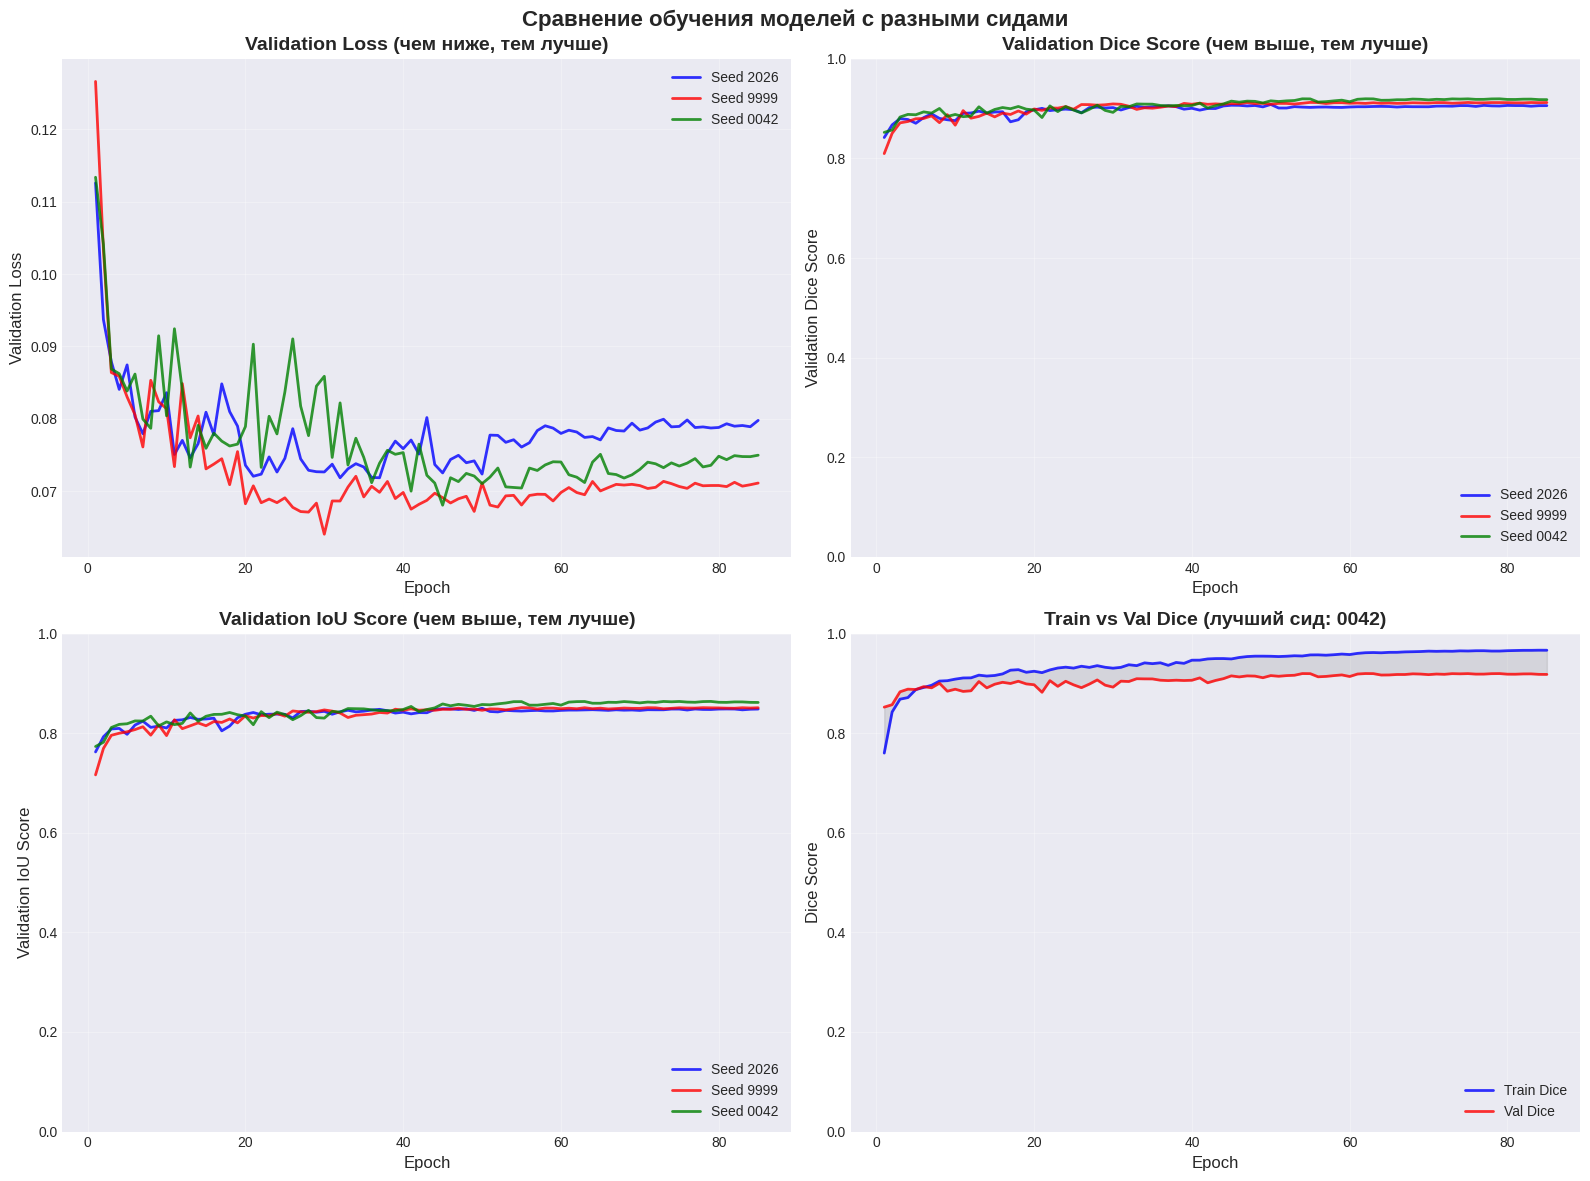


ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ СИДАМ

Seed 2026:
  Лучший Dice: 0.9084 (эпоха 50)
  Лучший IoU:  0.8501 (эпоха 50)
  Лучший Loss: 0.0719 (эпоха 32)
  Финальный Dice: 0.9060
  Разрыв Train-Val: 0.0574

Seed 9999:
  Лучший Dice: 0.9126 (эпоха 55)
  Лучший IoU:  0.8513 (эпоха 55)
  Лучший Loss: 0.0641 (эпоха 30)
  Финальный Dice: 0.9123
  Разрыв Train-Val: 0.0526

Seed 0042:
  Лучший Dice: 0.9197 (эпоха 62)
  Лучший IoU:  0.8638 (эпоха 79)
  Лучший Loss: 0.0681 (эпоха 45)
  Финальный Dice: 0.9180
  Разрыв Train-Val: 0.0469

ВЫБОР ЛУЧШЕЙ МОДЕЛИ

Лучшая модель по Dice: Seed 0042
  Лучший Dice: 0.9197 (эпоха 62)
  Лучший IoU: 0.8638
  Разрыв Train-Val: 0.0469

Статистика сохранена: seed_comparison.csv

СОЗДАНИЕ ОТДЕЛЬНЫХ ГРАФИКОВ ДЛЯ КАЖДОГО СИДА
График сохранен: training_curves_seed_2026.png
График сохранен: training_curves_seed_9999.png
График сохранен: training_curves_seed_0042.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path



print("=" * 60)
print("ПОИСК ФАЙЛОВ ОБУЧЕНИЯ")
print("=" * 60)


seed_dirs = []
for p in Path(".").rglob("history.csv"):
    seed_dirs.append(p.parent)
    print(f"Найден: {p.parent}/history.csv")

if not seed_dirs:
    print("Ошибка")
    exit()


all_data = {}
for seed_dir in seed_dirs:
    history_path = seed_dir / "history.csv"
    df = pd.read_csv(history_path)

    # Извлекаем номер сида из имени папки
    seed_name = seed_dir.name
    if "seed_" in seed_name:
        seed_num = seed_name.replace("seed_", "")
    elif "seed" in seed_name:
        seed_num = seed_name.replace("seed", "")
    else:
        seed_num = seed_name

    all_data[seed_num] = df
    print(f"Загружено {len(df)} эпох для seed {seed_num}")


plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Сравнение обучения моделей с разными сидами', fontsize=16, fontweight='bold')

colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

ax = axes[0, 0]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_loss'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss (чем ниже, тем лучше)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_dice'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Dice Score', fontsize=12)
ax.set_title('Validation Dice Score (чем выше, тем лучше)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])


ax = axes[1, 0]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_iou'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation IoU Score', fontsize=12)
ax.set_title('Validation IoU Score (чем выше, тем лучше)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

ax = axes[1, 1]

best_seed = None
best_dice = -1
for seed_num, df in all_data.items():
    max_dice = df['val_dice'].max()
    if max_dice > best_dice:
        best_dice = max_dice
        best_seed = seed_num

if best_seed is not None:
    df_best = all_data[best_seed]
    ax.plot(df_best['epoch'], df_best['train_dice'], 'b-', label='Train Dice', linewidth=2, alpha=0.8)
    ax.plot(df_best['epoch'], df_best['val_dice'], 'r-', label='Val Dice', linewidth=2, alpha=0.8)
    ax.fill_between(df_best['epoch'], df_best['train_dice'], df_best['val_dice'], alpha=0.2, color='gray')
    ax.set_title(f'Train vs Val Dice (лучший сид: {best_seed})', fontsize=14, fontweight='bold')
else:
    ax.set_title('Train vs Val Dice', fontsize=14, fontweight='bold')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Dice Score', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()

save_path = Path("./training_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"\nГрафик сохранен: {save_path}")

plt.show()

print("\n" + "=" * 70)
print("ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ СИДАМ")
print("=" * 70)

results = []
for seed_num, df in all_data.items():
    best_dice = df['val_dice'].max()
    best_dice_epoch = df['val_dice'].idxmax() + 1
    best_iou = df['val_iou'].max()
    best_iou_epoch = df['val_iou'].idxmax() + 1
    best_loss = df['val_loss'].min()
    best_loss_epoch = df['val_loss'].idxmin() + 1
    final_dice = df['val_dice'].iloc[-1]

    # Проверка на переобучение
    max_train_dice = df['train_dice'].max()
    gap_dice = max_train_dice - best_dice

    results.append({
        'seed': seed_num,
        'best_dice': best_dice,
        'best_dice_epoch': best_dice_epoch,
        'best_iou': best_iou,
        'best_iou_epoch': best_iou_epoch,
        'best_loss': best_loss,
        'best_loss_epoch': best_loss_epoch,
        'final_dice': final_dice,
        'overfitting_gap': gap_dice
    })

    print(f"\nSeed {seed_num}:")
    print(f"  Лучший Dice: {best_dice:.4f} (эпоха {best_dice_epoch})")
    print(f"  Лучший IoU:  {best_iou:.4f} (эпоха {best_iou_epoch})")
    print(f"  Лучший Loss: {best_loss:.4f} (эпоха {best_loss_epoch})")
    print(f"  Финальный Dice: {final_dice:.4f}")
    print(f"  Разрыв Train-Val: {gap_dice:.4f}")


print("\n" + "=" * 70)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("=" * 70)

best_result = max(results, key=lambda x: x['best_dice'])
print(f"\nЛучшая модель по Dice: Seed {best_result['seed']}")
print(f"  Лучший Dice: {best_result['best_dice']:.4f} (эпоха {best_result['best_dice_epoch']})")
print(f"  Лучший IoU: {best_result['best_iou']:.4f}")
print(f"  Разрыв Train-Val: {best_result['overfitting_gap']:.4f}")


stats_df = pd.DataFrame(results)
stats_csv = Path("./seed_comparison.csv")
stats_df.to_csv(stats_csv, index=False)
print(f"\nСтатистика сохранена: {stats_csv}")


print("\n" + "=" * 70)
print("СОЗДАНИЕ ОТДЕЛЬНЫХ ГРАФИКОВ ДЛЯ КАЖДОГО СИДА")
print("=" * 70)

for seed_num, df in all_data.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Обучение модели (Seed {seed_num})', fontsize=16, fontweight='bold')


    ax = axes[0, 0]
    ax.plot(df['epoch'], df['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(df['epoch'], df['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax.fill_between(df['epoch'], df['train_loss'], df['val_loss'], alpha=0.2, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df['epoch'], df['train_dice'], 'b-', label='Train Dice', linewidth=2)
    ax.plot(df['epoch'], df['val_dice'], 'r-', label='Val Dice', linewidth=2)
    ax.fill_between(df['epoch'], df['train_dice'], df['val_dice'], alpha=0.2, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Dice Score')
    ax.set_title('Dice Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 0]
    ax.plot(df['epoch'], df['train_iou'], 'b-', label='Train IoU', linewidth=2)
    ax.plot(df['epoch'], df['val_iou'], 'r-', label='Val IoU', linewidth=2)
    ax.fill_between(df['epoch'], df['train_iou'], df['val_iou'], alpha=0.2, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('IoU Score')
    ax.set_title('IoU Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 1]
    ax.plot(df['epoch'], df['lr'], 'g-', linewidth=2)
    ax.fill_between(df['epoch'], 0, df['lr'], alpha=0.2, color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.tight_layout()

    save_path = Path(f"./training_curves_seed_{seed_num}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"График сохранен: {save_path}")

    plt.close()

ПОИСК ФАЙЛОВ ОБУЧЕНИЯ
Найден: seg_train_runs/seed_2026/history.csv
Найден: seg_train_runs/seed_9999/history.csv
Найден: seg_train_runs/seed_0042/history.csv
Загружено 85 эпох для seed 2026
Загружено 85 эпох для seed 9999
Загружено 85 эпох для seed 0042
График сохранен: loss_curves_seed_2026.png


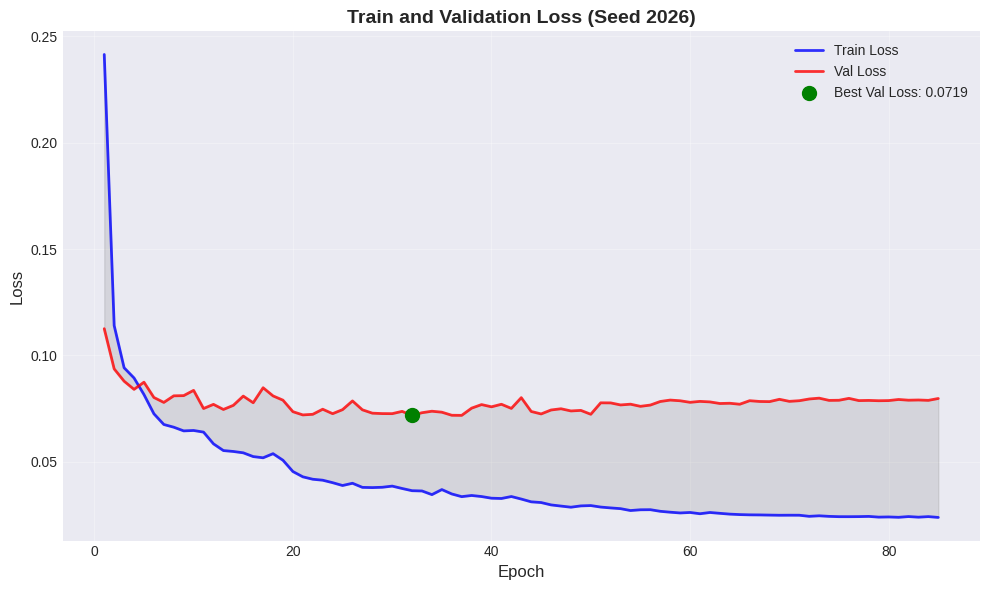

График сохранен: loss_curves_seed_9999.png


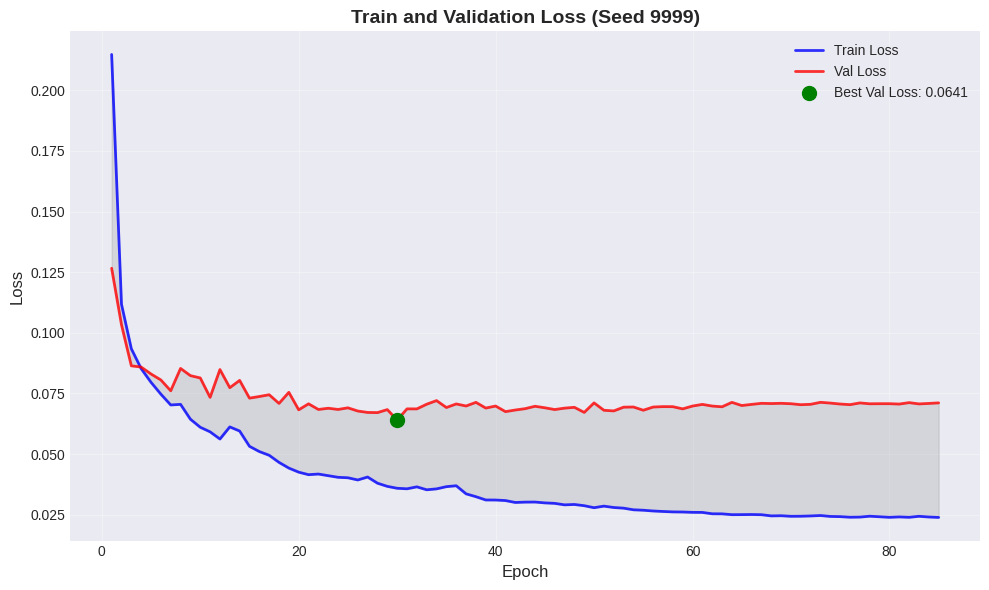

График сохранен: loss_curves_seed_0042.png


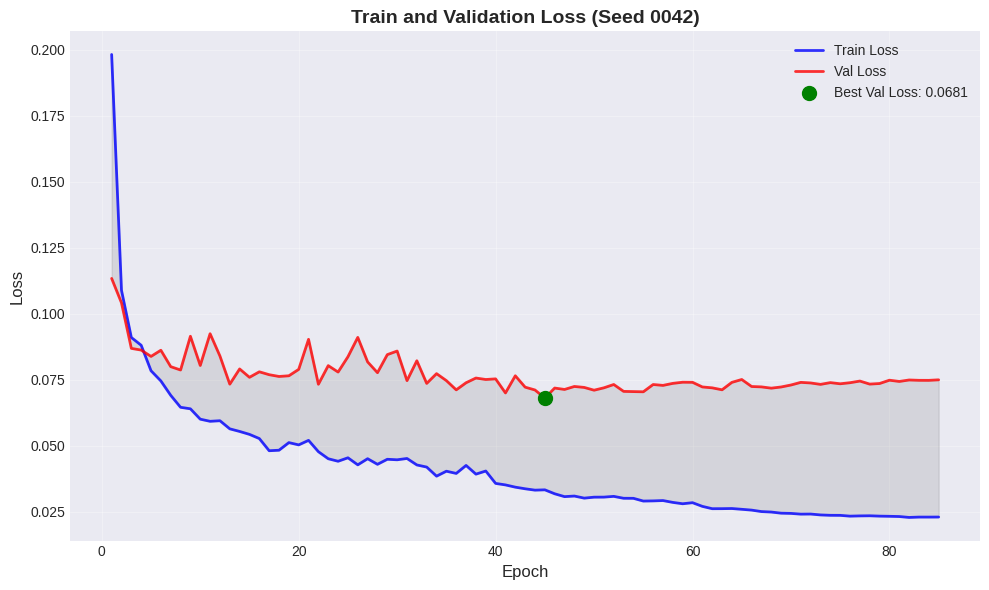


Сводный график сохранен: loss_comparison_all_seeds.png


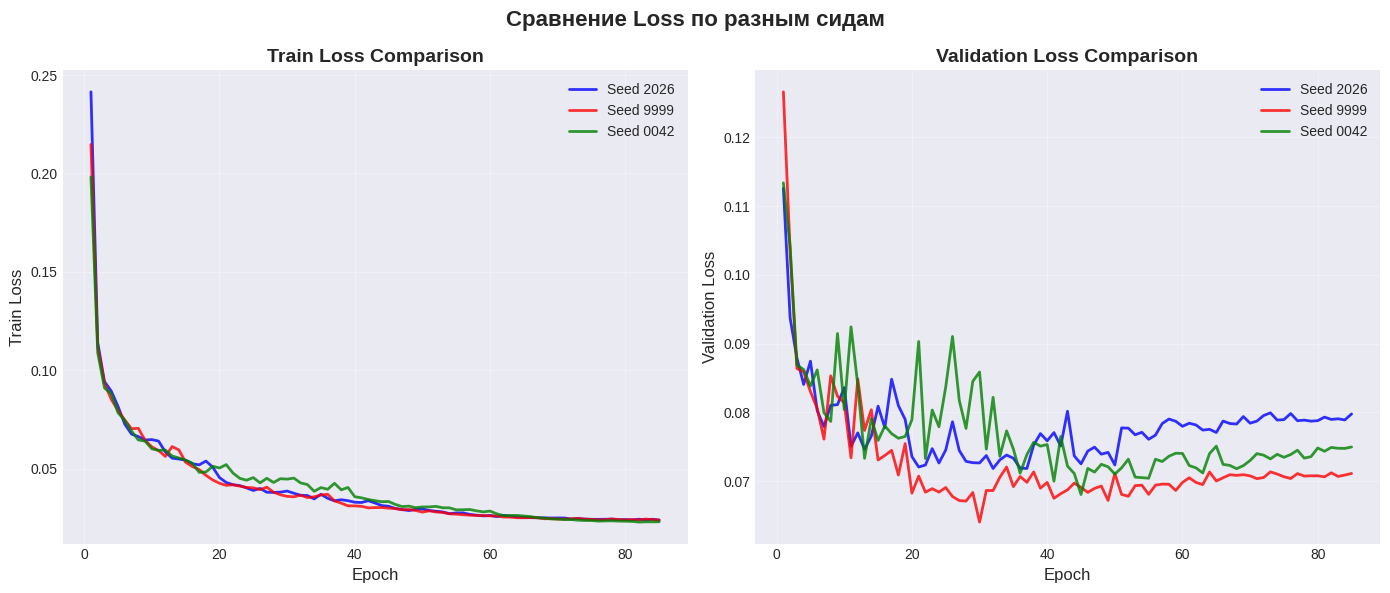


ИТОГОВАЯ СТАТИСТИКА

Seed 2026:
  Лучший Train Loss: 0.0239
  Лучший Val Loss:   0.0719
  Финальный Train Loss: 0.0239
  Финальный Val Loss:   0.0798

Seed 9999:
  Лучший Train Loss: 0.0239
  Лучший Val Loss:   0.0641
  Финальный Train Loss: 0.0239
  Финальный Val Loss:   0.0711

Seed 0042:
  Лучший Train Loss: 0.0228
  Лучший Val Loss:   0.0681
  Финальный Train Loss: 0.0230
  Финальный Val Loss:   0.0750


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


print("=" * 60)
print("ПОИСК ФАЙЛОВ ОБУЧЕНИЯ")
print("=" * 60)

seed_dirs = []
for p in Path(".").rglob("history.csv"):
    seed_dirs.append(p.parent)
    print(f"Найден: {p.parent}/history.csv")

if not seed_dirs:
    print("Ошибка")
    exit()

all_data = {}
for seed_dir in seed_dirs:
    history_path = seed_dir / "history.csv"
    df = pd.read_csv(history_path)

    seed_name = seed_dir.name
    if "seed_" in seed_name:
        seed_num = seed_name.replace("seed_", "")
    else:
        seed_num = seed_name

    all_data[seed_num] = df
    print(f"Загружено {len(df)} эпох для seed {seed_num}")

plt.style.use('seaborn-v0_8-darkgrid')

for seed_num, df in all_data.items():
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(df['epoch'], df['train_loss'], 'b-', label='Train Loss', linewidth=2, alpha=0.8)
    ax.plot(df['epoch'], df['val_loss'], 'r-', label='Val Loss', linewidth=2, alpha=0.8)
    ax.fill_between(df['epoch'], df['train_loss'], df['val_loss'], alpha=0.2, color='gray')

    best_val_loss_epoch = df['val_loss'].idxmin() + 1
    best_val_loss = df['val_loss'].min()

    ax.scatter(best_val_loss_epoch, best_val_loss, color='green', s=100, zorder=5,
               label=f'Best Val Loss: {best_val_loss:.4f}')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Train and Validation Loss (Seed {seed_num})', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    save_path = Path(f"./loss_curves_seed_{seed_num}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"График сохранен: {save_path}")

    plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Сравнение Loss по разным сидам', fontsize=16, fontweight='bold')

colors = ['blue', 'red', 'green']

ax = axes[0]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['train_loss'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Train Loss', fontsize=12)
ax.set_title('Train Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_loss'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = Path("./loss_comparison_all_seeds.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"\nСводный график сохранен: {save_path}")
plt.show()


print("\n" + "=" * 60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("=" * 60)

for seed_num, df in all_data.items():
    best_train_loss = df['train_loss'].min()
    best_val_loss = df['val_loss'].min()
    final_train_loss = df['train_loss'].iloc[-1]
    final_val_loss = df['val_loss'].iloc[-1]

    print(f"\nSeed {seed_num}:")
    print(f"  Лучший Train Loss: {best_train_loss:.4f}")
    print(f"  Лучший Val Loss:   {best_val_loss:.4f}")
    print(f"  Финальный Train Loss: {final_train_loss:.4f}")
    print(f"  Финальный Val Loss:   {final_val_loss:.4f}")

In [ ]:
from pathlib import Path

seeds = [9999, 42, 2026]

print("=" * 60)
print("ПРОВЕРКА ФАЙЛОВ ОБУЧЕНИЯ ДЛЯ РАЗНЫХ СИДОВ")
print("=" * 60)

for seed in seeds:
    possible_paths = [
        Path(f"./seg_train_runs/seed_{seed}"),
        Path(f"./seg_train_runs_seed_{seed}"),
        Path(f"./seg_train_runs/seed_{seed:04d}"),
        Path(f"./seg_train_runs_seed_{seed:04d}"),
    ]

    found = False
    for save_dir in possible_paths:
        if save_dir.exists():
            best_pth = save_dir / "best.pth"
            last_pth = save_dir / "last.pth"
            history_csv = save_dir / "history.csv"

            print(f"\nSeed {seed}:")
            print(f"  Папка: {save_dir}")
            print(f"  best.pth    exists: {best_pth.exists()} (размер: {best_pth.stat().st_size if best_pth.exists() else 0} bytes)")
            print(f"  last.pth    exists: {last_pth.exists()} (размер: {last_pth.stat().st_size if last_pth.exists() else 0} bytes)")
            print(f"  history.csv exists: {history_csv.exists()}")

            if history_csv.exists():
                import pandas as pd
                df = pd.read_csv(history_csv)
                print(f"  Эпох в history.csv: {len(df)}")
                print(f"  Лучший val_dice: {df['val_dice'].max():.4f}")

            found = True
            break

    if not found:
        print(f"\nSeed {seed}: НЕ НАЙДЕНО")
        print(f"  Искали в:")
        for save_dir in possible_paths:
            print(f"    {save_dir}")

print("\n" + "=" * 60)
print("ПОИСК ВСЕХ ПАПОК С ОБУЧЕНИЕМ")
print("=" * 60)


all_seed_dirs = []
for pattern in ["seg_train_runs/seed_*", "seg_train_runs_seed_*"]:
    for p in Path(".").glob(pattern):
        if p.is_dir():
            all_seed_dirs.append(p)

if all_seed_dirs:
    print(f"\nНайдено папок: {len(all_seed_dirs)}")
    for p in sorted(all_seed_dirs):
        print(f"  {p}/")
else:
    print("\nНе найдено ни одной папки с обучением")


print("\n" + "=" * 60)
print("ДЕТАЛЬНАЯ ПРОВЕРКА КАЖДОЙ ПАПКИ")
print("=" * 60)

for save_dir in sorted(all_seed_dirs):
    best_pth = save_dir / "best.pth"
    last_pth = save_dir / "last.pth"
    history_csv = save_dir / "history.csv"

    print(f"\nПапка: {save_dir}")
    print(f"  best.pth:    {'Есть' if best_pth.exists() else 'Нет'}")
    print(f"  last.pth:    {'Есть' if last_pth.exists() else 'Нет'}")
    print(f"  history.csv: {'Есть' if history_csv.exists() else 'Нет'}")

    if history_csv.exists():
        import pandas as pd
        df = pd.read_csv(history_csv)
        print(f"  Всего эпох: {len(df)}")
        print(f"  Лучший val_dice: {df['val_dice'].max():.4f} (эпоха {df['val_dice'].idxmax() + 1})")
        print(f"  Лучший val_iou: {df['val_iou'].max():.4f}")
        print(f"  Финальный val_dice: {df['val_dice'].iloc[-1]:.4f}")





ПРОВЕРКА ФАЙЛОВ ОБУЧЕНИЯ ДЛЯ РАЗНЫХ СИДОВ

Seed 9999:
  Папка: seg_train_runs/seed_9999
  best.pth    exists: True (размер: 159634713 bytes)
  last.pth    exists: True (размер: 159634713 bytes)
  history.csv exists: True
  Эпох в history.csv: 85
  Лучший val_dice: 0.9126

Seed 42:
  Папка: seg_train_runs/seed_0042
  best.pth    exists: True (размер: 159634713 bytes)
  last.pth    exists: True (размер: 159634713 bytes)
  history.csv exists: True
  Эпох в history.csv: 85
  Лучший val_dice: 0.9197

Seed 2026:
  Папка: seg_train_runs/seed_2026
  best.pth    exists: True (размер: 159634713 bytes)
  last.pth    exists: True (размер: 159634713 bytes)
  history.csv exists: True
  Эпох в history.csv: 85
  Лучший val_dice: 0.9084

ПОИСК ВСЕХ ПАПОК С ОБУЧЕНИЕМ

Найдено папок: 3
  seg_train_runs/seed_0042/
  seg_train_runs/seed_2026/
  seg_train_runs/seed_9999/

ДЕТАЛЬНАЯ ПРОВЕРКА КАЖДОЙ ПАПКИ

Папка: seg_train_runs/seed_0042
  best.pth:    Есть
  last.pth:    Есть
  history.csv: Есть
  Всего эпох

In [ ]:
from pathlib import Path
import shutil
import pandas as pd


OUTPUT_ROOT = Path("/content/all_models")
OUTPUT_ROOT.mkdir(exist_ok=True, parents=True)

seeds = [9999, 42, 2026]


alternative_paths = [
    lambda seed: Path(f"/content/seg_train_runs/seed_{seed}"),
    lambda seed: Path(f"/content/seg_train_runs/seed_{seed:04d}"),
]

print("=" * 60)
print("СБОР МОДЕЛЕЙ И HISTORY.CSV")
print("=" * 60)

copied_models = 0
copied_history = 0

for seed in seeds:

    save_dir = None
    possible_dirs = [
        Path(f"/content/seg_train_runs_seed_{seed}"),
        Path(f"/content/seg_train_runs/seed_{seed}"),
        Path(f"/content/seg_train_runs/seed_{seed:04d}"),
        Path(f"/content/seg_train_runs_seed_{seed:04d}"),
    ]

    for p in possible_dirs:
        if p.exists():
            save_dir = p
            break

    if save_dir is None:
        print(f"\nSeed {seed}: ПАПКА НЕ НАЙДЕНА")
        print(f"  Искали в: {[str(p) for p in possible_dirs]}")
        continue

    best_pth = save_dir / "best.pth"
    last_pth = save_dir / "last.pth"
    history_csv = save_dir / "history.csv"

    print(f"\nSeed {seed}:")
    print(f"  Папка: {save_dir}")


    if best_pth.exists():
        dst = OUTPUT_ROOT / f"best_seed_{seed:04d}.pth"
        shutil.copy(best_pth, dst)
        print(f"  скопирован best.pth -> {dst.name} (размер: {best_pth.stat().st_size / 1024 / 1024:.2f} MB)")
        copied_models += 1
    else:
        print(f"  best.pth не найден")


    if last_pth.exists():
        dst = OUTPUT_ROOT / f"last_seed_{seed:04d}.pth"
        shutil.copy(last_pth, dst)
        print(f"  скопирован last.pth -> {dst.name} (размер: {last_pth.stat().st_size / 1024 / 1024:.2f} MB)")
        copied_models += 1
    else:
        print(f"  last.pth не найден")


    if history_csv.exists():
        dst = OUTPUT_ROOT / f"history_seed_{seed:04d}.csv"
        shutil.copy(history_csv, dst)
        print(f"  скопирован history.csv -> {dst.name}")

        df = pd.read_csv(history_csv)
        best_dice = df['val_dice'].max()
        best_epoch = df['val_dice'].idxmax() + 1
        print(f"    Лучший val_dice: {best_dice:.4f} (эпоха {best_epoch})")
        copied_history += 1
    else:
        print(f"  history.csv не найден")

print("\n" + "=" * 60)
print("СОЗДАНИЕ СВОДНОГО ОТЧЕТА")
print("=" * 60)

summary_data = []

for seed in seeds:

    history_path = None
    possible_history = [
        OUTPUT_ROOT / f"history_seed_{seed:04d}.csv",
        Path(f"/content/seg_train_runs_seed_{seed}") / "history.csv",
        Path(f"/content/seg_train_runs/seed_{seed}") / "history.csv",
        Path(f"/content/seg_train_runs/seed_{seed:04d}") / "history.csv",
    ]

    for p in possible_history:
        if p.exists():
            history_path = p
            break

    if history_path:
        df = pd.read_csv(history_path)
        summary_data.append({
            'seed': seed,
            'best_val_dice': df['val_dice'].max(),
            'best_val_dice_epoch': df['val_dice'].idxmax() + 1,
            'best_val_iou': df['val_iou'].max(),
            'best_val_iou_epoch': df['val_iou'].idxmax() + 1,
            'best_val_loss': df['val_loss'].min(),
            'best_val_loss_epoch': df['val_loss'].idxmin() + 1,
            'final_val_dice': df['val_dice'].iloc[-1],
            'final_val_iou': df['val_iou'].iloc[-1],
            'num_epochs': len(df)
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    summary_csv = OUTPUT_ROOT / "all_models_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print(f"Сводный отчет сохранен: {summary_csv}")


    print(summary_df.to_string(index=False))


    best_row = summary_df.loc[summary_df['best_val_dice'].idxmax()]
    print(f"\nЛУЧШАЯ МОДЕЛЬ:")
    print(f"  Seed: {best_row['seed']}")
    print(f"  Best val_dice: {best_row['best_val_dice']:.4f} (эпоха {best_row['best_val_dice_epoch']})")
    print(f"  Best val_iou: {best_row['best_val_iou']:.4f}")
else:
    print("Не найдено ни одного history.csv для создания отчета")


import zipfile

zip_path = OUTPUT_ROOT / "all_models.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in OUTPUT_ROOT.iterdir():
        if file.is_file() and file.suffix in ['.pth', '.csv']:
            zipf.write(file, arcname=file.name)
            print(f"  Добавлен: {file.name}")

print(f"\nАрхив создан: {zip_path}")
print(f"Размер архива: {zip_path.stat().st_size / 1024 / 1024:.2f} MB")



СБОР МОДЕЛЕЙ И HISTORY.CSV

Seed 9999:
  Папка: /content/seg_train_runs/seed_9999
  скопирован best.pth -> best_seed_9999.pth (размер: 152.24 MB)
  скопирован last.pth -> last_seed_9999.pth (размер: 152.24 MB)
  скопирован history.csv -> history_seed_9999.csv
    Лучший val_dice: 0.9126 (эпоха 55)

Seed 42:
  Папка: /content/seg_train_runs/seed_0042
  скопирован best.pth -> best_seed_0042.pth (размер: 152.24 MB)
  скопирован last.pth -> last_seed_0042.pth (размер: 152.24 MB)
  скопирован history.csv -> history_seed_0042.csv
    Лучший val_dice: 0.9197 (эпоха 62)

Seed 2026:
  Папка: /content/seg_train_runs/seed_2026
  скопирован best.pth -> best_seed_2026.pth (размер: 152.24 MB)
  скопирован last.pth -> last_seed_2026.pth (размер: 152.24 MB)
  скопирован history.csv -> history_seed_2026.csv
    Лучший val_dice: 0.9084 (эпоха 50)

СОЗДАНИЕ СВОДНОГО ОТЧЕТА
Сводный отчет сохранен: /content/all_models/all_models_summary.csv
 seed  best_val_dice  best_val_dice_epoch  best_val_iou  best_val_

In [ ]:
from google.colab import files
files.download('/content/all_models/all_models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
from segmentation_models_pytorch.encoders import get_preprocessing_fn



INFER_CONFIG: Dict[str, Any] = {
    "TEST_IMAGES_DIR": "/content/лаба3_го_3/dl-lab-3-product-segmentation/test_images",
    "OUTPUT_CSV": "submission.csv",
    "CHECKPOINT_PATHS": [
        "/content/seg_train_runs/seed_9999/best.pth",
        "/content/seg_train_runs/seed_0042/best.pth",
        "/content/seg_train_runs/seed_2026/best.pth",
    ],
    "MODEL_WEIGHTS": [1.0/3, 1.0/3, 1.0/3],
    "THRESHOLD": 0.5,
    "USE_TTA": True,
    "USE_PATCH_INFERENCE": False,
    "PATCH_SIZE": None,
    "PATCH_OVERLAP": 0.25,
}


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def cv2_imread_unicode(path: Path, flags: int = cv2.IMREAD_COLOR) -> Optional[np.ndarray]:
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)


def serialize_mask(mask2d: np.ndarray) -> str:
    return json.dumps(mask2d.astype(np.uint8).tolist(), separators=(",", ":"))


def sigmoid_np(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-x))


def collect_image_paths(images_dir: Path) -> List[Path]:
    return sorted([p for p in images_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])


def normalize_weights(weights: Optional[Sequence[float]], n_models: int) -> List[float]:
    if n_models <= 0:
        raise ValueError("n_models must be > 0")
    if weights is None or len(weights) == 0:
        return [1.0 / n_models] * n_models
    if len(weights) != n_models:
        raise ValueError(f"MODEL_WEIGHTS length ({len(weights)}) != number of models ({n_models})")
    arr = np.asarray(weights, dtype=np.float32)
    if np.any(arr < 0):
        raise ValueError("MODEL_WEIGHTS must be non-negative")
    total = float(arr.sum())
    if total <= 0:
        raise ValueError("MODEL_WEIGHTS sum must be > 0")
    return (arr / total).tolist()



def build_model(model_name: str, encoder_name: str, encoder_weights: Optional[str] = None):
    key = model_name.lower()
    if key == "unet":
        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    if key == "unetplusplus":
        return smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    if key == "fpn":
        return smp.FPN(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    raise ValueError(f"Unsupported MODEL_NAME: {model_name}")


def load_models_for_ensemble(
    checkpoint_paths: Sequence[str],
    model_weights: Optional[Sequence[float]],
    device: str,
) -> Tuple[List[Dict[str, Any]], List[float]]:
    model_entries: List[Dict[str, Any]] = []

    for checkpoint_path in checkpoint_paths:
        ckpt_path = Path(checkpoint_path)
        if not ckpt_path.exists():
            print(f"Warning: Checkpoint not found: {ckpt_path}")
            continue

        checkpoint = torch.load(ckpt_path, map_location="cpu")
        cfg = checkpoint.get("config", {})

        model_name = cfg.get("MODEL_NAME", "UnetPlusPlus")
        encoder_name = cfg.get("ENCODER_NAME", "timm-efficientnet-b3")
        encoder_weights = cfg.get("ENCODER_WEIGHTS", None)
        img_size = int(cfg.get("IMG_SIZE", 512))

        model = build_model(
            model_name=model_name,
            encoder_name=encoder_name,
            encoder_weights=None,
        )
        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)
        model.eval()

        preprocess_input = None
        if encoder_weights is not None:
            preprocess_input = get_preprocessing_fn(encoder_name, pretrained=encoder_weights)

        model_entries.append(
            {
                "checkpoint_path": str(ckpt_path),
                "model": model,
                "model_name": model_name,
                "encoder_name": encoder_name,
                "encoder_weights": encoder_weights,
                "img_size": img_size,
                "preprocess_input": preprocess_input,
            }
        )
        print(f"Loaded: {ckpt_path} | MODEL={model_name} | ENCODER={encoder_name} | IMG_SIZE={img_size}")

    if len(model_entries) == 0:
        raise RuntimeError("No valid models loaded. Check checkpoint paths.")

    normalized_weights = normalize_weights(model_weights, len(model_entries))
    return model_entries, normalized_weights


def prepare_input_tensor(
    image_rgb: np.ndarray,
    preprocess_input=None,
    resize_to: Optional[int] = None,
) -> torch.Tensor:
    x = image_rgb
    if resize_to is not None and (x.shape[0] != resize_to or x.shape[1] != resize_to):
        x = cv2.resize(x, (resize_to, resize_to), interpolation=cv2.INTER_LINEAR)
    x = x.astype(np.float32)
    if preprocess_input is not None:
        x = preprocess_input(x)
    else:
        x /= 255.0
    x = np.ascontiguousarray(x.transpose(2, 0, 1))
    return torch.from_numpy(x).float().unsqueeze(0)


@torch.no_grad()
def tta_inference(
    model: torch.nn.Module,
    input_tensor: torch.Tensor,
    use_tta: bool,
) -> torch.Tensor:
    logits_list = [model(input_tensor)]
    if use_tta:
        x = torch.flip(input_tensor, dims=[-1])
        logits_h = torch.flip(model(x), dims=[-1])
        logits_list.append(logits_h)

        x = torch.flip(input_tensor, dims=[-2])
        logits_v = torch.flip(model(x), dims=[-2])
        logits_list.append(logits_v)

        x = torch.rot90(input_tensor, k=1, dims=[-2, -1])
        logits_r = torch.rot90(model(x), k=3, dims=[-2, -1])
        logits_list.append(logits_r)

        x_hv = torch.flip(torch.flip(input_tensor, dims=[-1]), dims=[-2])
        logits_hv = torch.flip(torch.flip(model(x_hv), dims=[-1]), dims=[-2])
        logits_list.append(logits_hv)

    return torch.stack(logits_list, dim=0).mean(dim=0)


def _resize_logits_to_original(logits_2d: np.ndarray, out_h: int, out_w: int) -> np.ndarray:
    if logits_2d.shape == (out_h, out_w):
        return logits_2d
    return cv2.resize(logits_2d.astype(np.float32), (out_w, out_h), interpolation=cv2.INTER_LINEAR)


@torch.no_grad()
def inference_single_model(
    model_entry: Dict[str, Any],
    image_rgb: np.ndarray,
    use_tta: bool,
    device: str,
) -> np.ndarray:
    h, w = image_rgb.shape[:2]
    input_tensor = prepare_input_tensor(
        image_rgb=image_rgb,
        preprocess_input=model_entry["preprocess_input"],
        resize_to=int(model_entry["img_size"]),
    ).to(device)
    logits = tta_inference(model_entry["model"], input_tensor, use_tta=use_tta)
    logits_2d = logits[0, 0].detach().cpu().numpy().astype(np.float32)
    return _resize_logits_to_original(logits_2d, out_h=h, out_w=w)


def _compute_window_starts(total: int, window: int, stride: int) -> List[int]:
    if total <= window:
        return [0]
    starts = list(range(0, total - window + 1, stride))
    if starts[-1] != total - window:
        starts.append(total - window)
    return starts


def _pad_image_for_patches(image_rgb: np.ndarray, patch_size: int) -> Tuple[np.ndarray, int, int]:
    h, w = image_rgb.shape[:2]
    pad_h = max(0, patch_size - h)
    pad_w = max(0, patch_size - w)
    if pad_h == 0 and pad_w == 0:
        return image_rgb, 0, 0
    padded = cv2.copyMakeBorder(
        image_rgb,
        top=0,
        bottom=pad_h,
        left=0,
        right=pad_w,
        borderType=cv2.BORDER_REFLECT_101,
    )
    return padded, pad_h, pad_w


@torch.no_grad()
def patch_inference(
    model_entry: Dict[str, Any],
    image_rgb: np.ndarray,
    patch_size: int,
    overlap: float,
    use_tta: bool,
    device: str,
) -> np.ndarray:
    if not (0.0 <= overlap < 1.0):
        raise ValueError("PATCH_OVERLAP must be in [0, 1).")
    if patch_size <= 0:
        raise ValueError("PATCH_SIZE must be > 0.")

    h, w = image_rgb.shape[:2]
    stride = max(1, int(patch_size * (1.0 - overlap)))

    padded, pad_h, pad_w = _pad_image_for_patches(image_rgb, patch_size=patch_size)
    ph, pw = padded.shape[:2]
    y_starts = _compute_window_starts(ph, patch_size, stride)
    x_starts = _compute_window_starts(pw, patch_size, stride)

    logits_sum = np.zeros((ph, pw), dtype=np.float32)
    logits_count = np.zeros((ph, pw), dtype=np.float32)

    for y0 in y_starts:
        for x0 in x_starts:
            patch = padded[y0 : y0 + patch_size, x0 : x0 + patch_size]
            input_tensor = prepare_input_tensor(
                image_rgb=patch,
                preprocess_input=model_entry["preprocess_input"],
                resize_to=None,
            ).to(device)
            logits = tta_inference(model_entry["model"], input_tensor, use_tta=use_tta)
            patch_logits = logits[0, 0].detach().cpu().numpy().astype(np.float32)

            if patch_logits.shape != (patch_size, patch_size):
                patch_logits = cv2.resize(
                    patch_logits,
                    (patch_size, patch_size),
                    interpolation=cv2.INTER_LINEAR,
                )

            logits_sum[y0 : y0 + patch_size, x0 : x0 + patch_size] += patch_logits
            logits_count[y0 : y0 + patch_size, x0 : x0 + patch_size] += 1.0

    merged_logits = logits_sum / np.maximum(logits_count, 1e-6)
    if pad_h > 0:
        merged_logits = merged_logits[:-pad_h, :]
    if pad_w > 0:
        merged_logits = merged_logits[:, :-pad_w]
    return merged_logits[:h, :w]


def ensemble_inference(
    model_entries: Sequence[Dict[str, Any]],
    model_weights: Sequence[float],
    image_rgb: np.ndarray,
    infer_config: Dict[str, Any],
    device: str,
) -> np.ndarray:
    if len(model_entries) == 0:
        raise ValueError("No models provided for ensemble inference.")
    if len(model_entries) != len(model_weights):
        raise ValueError("Model entries and model weights must have the same length.")

    h, w = image_rgb.shape[:2]
    ensemble_logits = np.zeros((h, w), dtype=np.float32)

    for weight, model_entry in zip(model_weights, model_entries):
        if infer_config["USE_PATCH_INFERENCE"]:
            patch_size = infer_config["PATCH_SIZE"] or int(model_entry["img_size"])
            logits = patch_inference(
                model_entry=model_entry,
                image_rgb=image_rgb,
                patch_size=int(patch_size),
                overlap=float(infer_config["PATCH_OVERLAP"]),
                use_tta=bool(infer_config["USE_TTA"]),
                device=device,
            )
        else:
            logits = inference_single_model(
                model_entry=model_entry,
                image_rgb=image_rgb,
                use_tta=bool(infer_config["USE_TTA"]),
                device=device,
            )
        ensemble_logits += float(weight) * logits

    return ensemble_logits


def inference(
    model_entries: Sequence[Dict[str, Any]],
    model_weights: Sequence[float],
    image_rgb: np.ndarray,
    infer_config: Dict[str, Any],
    device: str,
) -> np.ndarray:
    logits = ensemble_inference(
        model_entries=model_entries,
        model_weights=model_weights,
        image_rgb=image_rgb,
        infer_config=infer_config,
        device=device,
    )
    probs = sigmoid_np(logits)
    return (probs > float(infer_config["THRESHOLD"])).astype(np.uint8)


if __name__ == "__main__":
    print("Loading models...")
    model_entries, model_weights = load_models_for_ensemble(
        checkpoint_paths=INFER_CONFIG["CHECKPOINT_PATHS"],
        model_weights=INFER_CONFIG.get("MODEL_WEIGHTS"),
        device=DEVICE,
    )
    print(f"Using {len(model_entries)} model(s) for inference with weights={model_weights}")

    test_images_dir = Path(INFER_CONFIG["TEST_IMAGES_DIR"])
    image_paths = collect_image_paths(test_images_dir)
    if not image_paths:
        raise FileNotFoundError(f"No images found in: {test_images_dir}")
    print(f"Found {len(image_paths)} test images")

    rows: List[Dict[str, Any]] = []
    for i, img_path in enumerate(image_paths, 1):
        img_bgr = cv2_imread_unicode(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"[skip] cannot read: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pred_mask = inference(
            model_entries=model_entries,
            model_weights=model_weights,
            image_rgb=img_rgb,
            infer_config=INFER_CONFIG,
            device=DEVICE,
        )

        rows.append({"ImageId": img_path.name, "mask": serialize_mask(pred_mask)})

        if i % 100 == 0 or i == len(image_paths):
            print(f"Processed {i}/{len(image_paths)}")

    submission_df = pd.DataFrame(rows)
    output_csv = Path(INFER_CONFIG["OUTPUT_CSV"])
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    submission_df.to_csv(output_csv, index=False, encoding="utf-8")

    print("Done.")
    print(f"Saved submission to: {output_csv}")
    print(submission_df.head())

Loading models...
Loaded: /content/seg_train_runs/seed_9999/best.pth | MODEL=UnetPlusPlus | ENCODER=timm-efficientnet-b3 | IMG_SIZE=512
Loaded: /content/seg_train_runs/seed_0042/best.pth | MODEL=UnetPlusPlus | ENCODER=timm-efficientnet-b3 | IMG_SIZE=512
Loaded: /content/seg_train_runs/seed_2026/best.pth | MODEL=UnetPlusPlus | ENCODER=timm-efficientnet-b3 | IMG_SIZE=512
Using 3 model(s) for inference with weights=[0.3333333432674408, 0.3333333432674408, 0.3333333432674408]
Found 2000 test images
Processed 100/2000
Processed 200/2000
Processed 300/2000
Processed 400/2000
Processed 500/2000
Processed 600/2000
Processed 700/2000
Processed 800/2000
Processed 900/2000
Processed 1000/2000
Processed 1100/2000
Processed 1200/2000
Processed 1300/2000
Processed 1400/2000
Processed 1500/2000
Processed 1600/2000
Processed 1700/2000
Processed 1800/2000
Processed 1900/2000
Processed 2000/2000
Done.
Saved submission to: submission.csv
                                             ImageId  \
0  10.107.2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Поиск history.csv файлов:")
history_files = list(Path("/content").rglob("history.csv"))

for f in history_files:
    print(f"  {f}")

if not history_files:
    print("\nОшибка: history.csv не найден!")
    print("Возможные пути с моделями:")
    for p in Path("/content").rglob("best.pth"):
        print(f"  {p.parent}")
else:

    history_path = history_files[0]
    print(f"\nЗагружаем: {history_path}")
    df = pd.read_csv(history_path)

    print("\n" + "="*50)
    print("ПЕРВЫЕ 5 СТРОК:")
    print("="*50)
    print(df.head())

    print("\n" + "="*50)
    print("КОЛОНКИ:")
    print("="*50)
    print(df.columns.tolist())

Поиск history.csv файлов:
  /content/seg_train_runs/seed_2026/history.csv
  /content/seg_train_runs/seed_9999/history.csv
  /content/seg_train_runs/seed_0042/history.csv

Загружаем: /content/seg_train_runs/seed_2026/history.csv

ПЕРВЫЕ 5 СТРОК:
   epoch      lr  train_loss  train_dice  train_iou  val_loss  val_dice  \
0      1  0.0003    0.241479    0.757863   0.653475  0.112594  0.842018   
1      2  0.0003    0.114067    0.845957   0.759721  0.093699  0.867353   
2      3  0.0003    0.094234    0.868126   0.789054  0.087913  0.879901   
3      4  0.0003    0.089429    0.872161   0.795806  0.084072  0.878146   
4      5  0.0003    0.081628    0.885004   0.812173  0.087454  0.870628   

    val_iou  
0  0.762373  
1  0.792781  
2  0.808445  
3  0.809584  
4  0.797688  

КОЛОНКИ:
['epoch', 'lr', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']


In [ ]:

import os

output_file = "submission.csv"
if "INFER_CONFIG" in globals():
    output_file = INFER_CONFIG.get("OUTPUT_CSV", output_file)

print("Файл сохранен в:", os.path.abspath(output_file))


Файл сохранен в: /content/submission.csv


In [ ]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>